# Function Templates

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def trimf(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    elif a < x <= b:
        return (x - a) / (b - a) if b != a else 1.0
    elif b < x < c:
        return (c - x) / (c - b) if c != b else 1.0
    return 0.0

def trapmf(x, a, b, c, d):
    if x < a or x > d:
        return 0.0
    elif a <= x <= b:
        return (x - a) / (b - a) if b != a else 1.0
    elif b < x <= c:
        return 1.0
    elif c < x <= d:
        return (d - x) / (d - c) if d != c else 1.0
    return 0.0

# Membership Functions for DAM


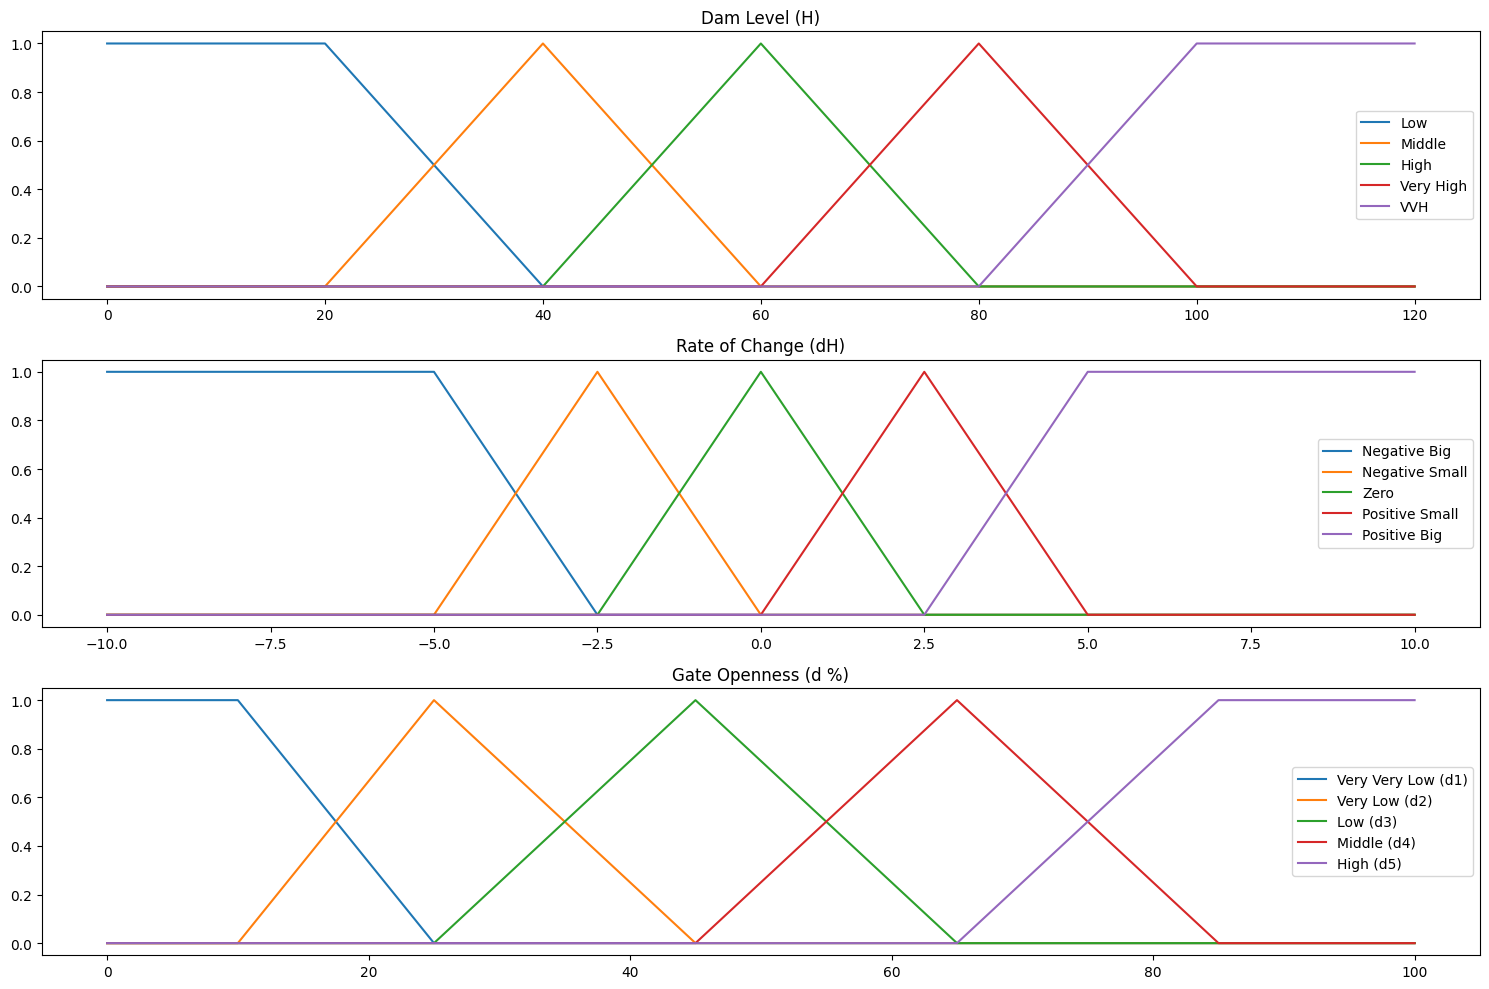

In [ ]:
# 1. define x-values
x_H = np.arange(0, 121, 1)       # Dam Level: 0 to 120
x_dH = np.arange(-10, 10.1, 0.1) # Rate of Change: -10 to +10
x_d = np.arange(0, 101, 1)       # Gate Openness: 0 to 100%

# 2. dam level (H) sets
mu_H_Low = [trapmf(x, 0, 0, 20, 40) for x in x_H]
mu_H_Mid = [trimf(x, 20, 40, 60) for x in x_H]
mu_H_High = [trimf(x, 40, 60, 80) for x in x_H]
mu_H_VH = [trimf(x, 60, 80, 100) for x in x_H]
mu_H_VVH = [trapmf(x, 80, 100, 120, 120) for x in x_H]

# 3. rate of change (dH) Sets
mu_dH_NB = [trapmf(x, -10, -10, -5, -2.5) for x in x_dH]
mu_dH_NS = [trimf(x, -5, -2.5, 0) for x in x_dH]
mu_dH_Z = [trimf(x, -2.5, 0, 2.5) for x in x_dH]
mu_dH_PS = [trimf(x, 0, 2.5, 5) for x in x_dH]
mu_dH_PB = [trapmf(x, 2.5, 5, 10, 10) for x in x_dH]

# 4. output - gate openness (d) Sets
mu_d_VVL = [trapmf(x, 0, 0, 10, 25) for x in x_d]
mu_d_VL = [trimf(x, 10, 25, 45) for x in x_d]
mu_d_L = [trimf(x, 25, 45, 65) for x in x_d]
mu_d_M = [trimf(x, 45, 65, 85) for x in x_d]
mu_d_H = [trapmf(x, 65, 85, 100, 100) for x in x_d]

# plot
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(x_H, mu_H_Low, label='Low')
plt.plot(x_H, mu_H_Mid, label='Middle')
plt.plot(x_H, mu_H_High, label='High')
plt.plot(x_H, mu_H_VH, label='Very High')
plt.plot(x_H, mu_H_VVH, label='VVH')
plt.title('Dam Level (H)')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(x_dH, mu_dH_NB, label='Negative Big')
plt.plot(x_dH, mu_dH_NS, label='Negative Small')
plt.plot(x_dH, mu_dH_Z, label='Zero')
plt.plot(x_dH, mu_dH_PS, label='Positive Small')
plt.plot(x_dH, mu_dH_PB, label='Positive Big')
plt.title('Rate of Change (dH)')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(x_d, mu_d_VVL, label='Very Very Low (d1)')
plt.plot(x_d, mu_d_VL, label='Very Low (d2)')
plt.plot(x_d, mu_d_L, label='Low (d3)')
plt.plot(x_d, mu_d_M, label='Middle (d4)')
plt.plot(x_d, mu_d_H, label='High (d5)')
plt.title('Gate Openness (d %)')
plt.legend()

plt.tight_layout()
plt.show()

# Rules Matrix

In [ ]:
def fuzzy_dam_controller(current_H, current_dH):
    # fuzzify inputs
    h = {
        "Low": trapmf(current_H, 0, 0, 20, 40),
        "Mid": trimf(current_H, 20, 40, 60),
        "High": trimf(current_H, 40, 60, 80),
        "VH": trimf(current_H, 60, 80, 100),
        "VVH": trapmf(current_H, 80, 100, 120, 120)
    }

    dh = {
        "NB": trapmf(current_dH, -10, -10, -5, -2.5),
        "NS": trimf(current_dH, -5, -2.5, 0),
        "Z": trimf(current_dH, -2.5, 0, 2.5),
        "PS": trimf(current_dH, 0, 2.5, 5),
        "PB": trapmf(current_dH, 2.5, 5, 10, 10)
    }

    # fuzzy rule matrix
    # Rules resulting in d1 (Very Very Low)
    rule_d1 = max(
        min(h["Low"], dh["NB"]), min(h["Low"], dh["NS"]), min(h["Low"], dh["Z"]), min(h["Low"], dh["PS"]),
        min(h["Mid"], dh["NB"]), min(h["Mid"], dh["NS"])
    )

    # Rules resulting in d2 (Very Low)
    rule_d2 = max(
        min(h["Low"], dh["PB"]),
        min(h["Mid"], dh["Z"]),
        min(h["High"], dh["NB"])
    )

    # Rules resulting in d3 (Low)
    rule_d3 = max(
        min(h["Mid"], dh["PS"]),
        min(h["High"], dh["NS"]),
        min(h["VH"], dh["NB"]), min(h["VH"], dh["NS"])
    )

    # Rules resulting in d4 (Middle)
    rule_d4 = max(
        min(h["Mid"], dh["PB"]),
        min(h["High"], dh["Z"]), min(h["High"], dh["PS"]),
        min(h["VH"], dh["Z"])
    )

    # Rules resulting in d5 (High)
    rule_d5 = max(
        min(h["High"], dh["PB"]),
        min(h["VH"], dh["PS"]), min(h["VH"], dh["PB"]),
        h["VVH"] # since vvh is d5 across ALL dH values, take VVH directly
    )

    # 3. aggregation & clipping
    out_x = np.arange(0, 101, 1)
    clip_d1 = np.array([min(rule_d1, trapmf(x, 0, 0, 10, 25)) for x in out_x])
    clip_d2 = np.array([min(rule_d2, trimf(x, 10, 25, 45)) for x in out_x])
    clip_d3 = np.array([min(rule_d3, trimf(x, 25, 45, 65)) for x in out_x])
    clip_d4 = np.array([min(rule_d4, trimf(x, 45, 65, 85)) for x in out_x])
    clip_d5 = np.array([min(rule_d5, trapmf(x, 65, 85, 100, 100)) for x in out_x])

    aggregated = np.maximum.reduce([clip_d1, clip_d2, clip_d3, clip_d4, clip_d5])

    # 4. deffuzification/Center of Gravity
    area = np.sum(aggregated)
    if area == 0:
        return 0.0

    cog = np.sum(out_x * aggregated) / area
    return cog

# Aggregation and Defuzzification

In [ ]:
def plot_fuzzy_decision(current_H, current_dH):
    # fuzzify inputs
    h = {
        "Low": trapmf(current_H, 0, 0, 20, 40),
        "Mid": trimf(current_H, 20, 40, 60),
        "High": trimf(current_H, 40, 60, 80),
        "VH": trimf(current_H, 60, 80, 100),
        "VVH": trapmf(current_H, 80, 100, 120, 120)
    }

    dh = {
        "NB": trapmf(current_dH, -10, -10, -5, -2.5),
        "NS": trimf(current_dH, -5, -2.5, 0),
        "Z": trimf(current_dH, -2.5, 0, 2.5),
        "PS": trimf(current_dH, 0, 2.5, 5),
        "PB": trapmf(current_dH, 2.5, 5, 10, 10)
    }

    # 2. rule matrix
    rule_d1 = max(min(h["Low"], dh["NB"]), min(h["Low"], dh["NS"]), min(h["Low"], dh["Z"]), min(h["Low"], dh["PS"]), min(h["Mid"], dh["NB"]), min(h["Mid"], dh["NS"]))
    rule_d2 = max(min(h["Low"], dh["PB"]), min(h["Mid"], dh["Z"]), min(h["High"], dh["NB"]))
    rule_d3 = max(min(h["Mid"], dh["PS"]), min(h["High"], dh["NS"]), min(h["VH"], dh["NB"]), min(h["VH"], dh["NS"]))
    rule_d4 = max(min(h["Mid"], dh["PB"]), min(h["High"], dh["Z"]), min(h["High"], dh["PS"]), min(h["VH"], dh["Z"]))
    rule_d5 = max(min(h["High"], dh["PB"]), min(h["VH"], dh["PS"]), min(h["VH"], dh["PB"]), h["VVH"])

    # 3. aggregation and clipping
    out_x = np.arange(0, 101, 1)

    # shapes for background reference
    orig_d1 = np.array([trapmf(x, 0, 0, 10, 25) for x in out_x])
    orig_d2 = np.array([trimf(x, 10, 25, 45) for x in out_x])
    orig_d3 = np.array([trimf(x, 25, 45, 65) for x in out_x])
    orig_d4 = np.array([trimf(x, 45, 65, 85) for x in out_x])
    orig_d5 = np.array([trapmf(x, 65, 85, 100, 100) for x in out_x])

    # clipped shapes
    clip_d1 = np.minimum(rule_d1, orig_d1)
    clip_d2 = np.minimum(rule_d2, orig_d2)
    clip_d3 = np.minimum(rule_d3, orig_d3)
    clip_d4 = np.minimum(rule_d4, orig_d4)
    clip_d5 = np.minimum(rule_d5, orig_d5)

    # final
    aggregated = np.maximum.reduce([clip_d1, clip_d2, clip_d3, clip_d4, clip_d5])

    # 4. defuzzification
    area = np.sum(aggregated)
    cog = np.sum(out_x * aggregated) / area if area != 0 else 0.0

    # plot
    plt.figure(figsize=(10, 5))

    plt.plot(out_x, orig_d1, 'k--', alpha=0.2)
    plt.plot(out_x, orig_d2, 'k--', alpha=0.2)
    plt.plot(out_x, orig_d3, 'k--', alpha=0.2)
    plt.plot(out_x, orig_d4, 'k--', alpha=0.2)
    plt.plot(out_x, orig_d5, 'k--', alpha=0.2)

    plt.fill_between(out_x, 0, aggregated, color='skyblue', alpha=0.7, label='Aggregated Area')
    plt.plot(out_x, aggregated, 'b-', linewidth=2)

    # COG line
    plt.vlines(cog, 0, 1, colors='red', linestyles='solid', linewidth=3, label=f'Center of Gravity (Gate: {cog:.2f}%)')

    plt.title(f'Fuzzy Decision for Dam Level = {current_H}m, Rate = {current_dH}m/hr')
    plt.xlabel('Gate Openness (%)')
    plt.ylabel('Membership Degree / Rule Strength')
    plt.xlim(0, 100)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Inputs

In [ ]:
steps = int(input("Enter Steps: "))
initial_H = float(input("Enter Initial Dam Level: "))

Enter Steps: 100
Enter Initial Dam Level: 200


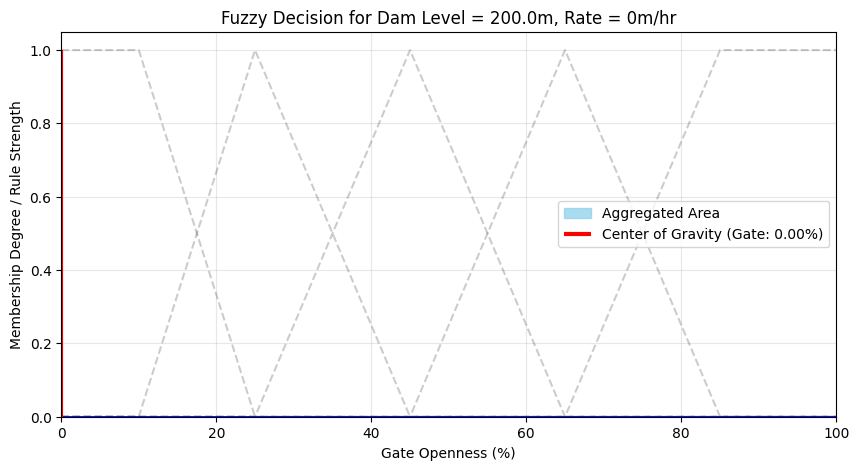

In [ ]:
# test
plot_fuzzy_decision(current_H=initial_H, current_dH=0)

#DAM Simulation

In [ ]:
def run_dam_simulation(steps=200, initial_H=50, inflow=2.6667):
    current_H = initial_H
    current_dH = 0.0 # Starting at steady state

    # Lists to store results for plotting
    history_H = []
    history_d = []
    history_dH = []

    print(f"{'Step':<5} | {'Level (H)':<10} | {'Rate (dH)':<10} | {'Gate %':<10}")
    print("-" * 45)

    for t in range(steps):
        # get openness based on current dam level
        gate_percent = fuzzy_dam_controller(current_H, current_dH)

        # print the state
        print(f"{t:<5} | {current_H:<10.2f} | {current_dH:<10.2f} | {gate_percent:<10.2f}%")

        # data for plotting
        history_H.append(current_H)
        history_d.append(gate_percent)
        history_dH.append(current_dH)

        outflow = gate_percent / 10.0
        current_dH = inflow - outflow
        current_H = current_H + current_dH

    return history_H, history_d, history_dH

# values
h_trace, gate_trace, dh_trace = run_dam_simulation(steps, initial_H)

Step  | Level (H)  | Rate (dH)  | Gate %    
---------------------------------------------
0     | 200.00     | 0.00       | 0.00      %
1     | 202.67     | 2.67       | 0.00      %
2     | 205.33     | 2.67       | 0.00      %
3     | 208.00     | 2.67       | 0.00      %
4     | 210.67     | 2.67       | 0.00      %
5     | 213.33     | 2.67       | 0.00      %
6     | 216.00     | 2.67       | 0.00      %
7     | 218.67     | 2.67       | 0.00      %
8     | 221.33     | 2.67       | 0.00      %
9     | 224.00     | 2.67       | 0.00      %
10    | 226.67     | 2.67       | 0.00      %
11    | 229.33     | 2.67       | 0.00      %
12    | 232.00     | 2.67       | 0.00      %
13    | 234.67     | 2.67       | 0.00      %
14    | 237.33     | 2.67       | 0.00      %
15    | 240.00     | 2.67       | 0.00      %
16    | 242.67     | 2.67       | 0.00      %
17    | 245.33     | 2.67       | 0.00      %
18    | 248.00     | 2.67       | 0.00      %
19    | 250.67     | 2.67       | 0

#DAM Simulation Plot

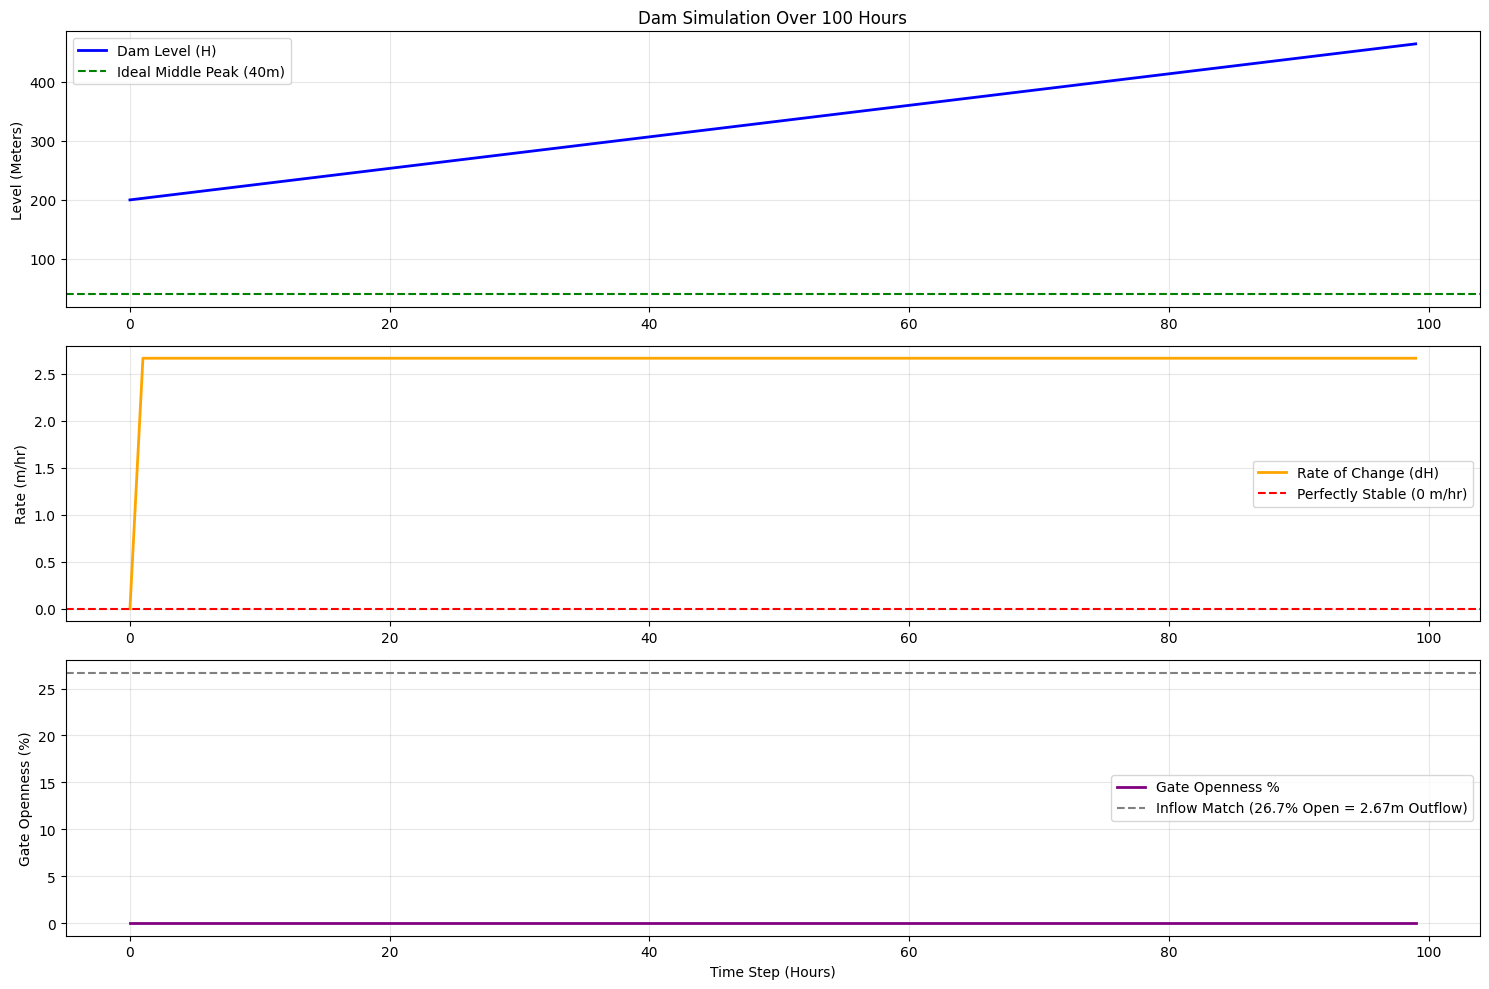

In [ ]:
plt.figure(figsize=(15, 10))

# dam level over time
plt.subplot(3, 1, 1)
plt.plot(h_trace, label='Dam Level (H)', color='blue', linewidth=2)
plt.axhline(y=40, color='green', linestyle='--', label='Ideal Middle Peak (40m)')
plt.title(f'Dam Simulation Over {len(h_trace)} Hours')
plt.ylabel('Level (Meters)')
plt.grid(True, alpha=0.3)
plt.legend()

# rate of change over time
plt.subplot(3, 1, 2)
plt.plot(dh_trace, label='Rate of Change (dH)', color='orange', linewidth=2)
plt.axhline(y=0, color='red', linestyle='--', label='Perfectly Stable (0 m/hr)')
plt.ylabel('Rate (m/hr)')
plt.grid(True, alpha=0.3)
plt.legend()

# gate openness
plt.subplot(3, 1, 3)
plt.plot(gate_trace, label='Gate Openness %', color='purple', linewidth=2)

# changed inflow to 2.67
plt.axhline(y=26.7, color='gray', linestyle='--', label='Inflow Match (26.7% Open = 2.67m Outflow)')
plt.xlabel('Time Step (Hours)')
plt.ylabel('Gate Openness (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()